# 🐍 Método LACA: Consolidação do Corpus em PDF, Deduplicação e Análise de Resultados

---

- **Autor:** Tiago Marafante Lins de Souza
- **Orientador:** Prof. Dr. Edans Flávius de Oliveira Sandes
- **Programa:** Mestrado Profissional em Controle da Administração Pública (MP-CAP)
- **Instituição:** Instituto Serzedello Corrêa / Tribunal de Contas da União (ISC/TCU)
- **Ano:** 2026
- **Repositório Oficial:** [ptt-instrumentos-governo-digital-e-agentico (GitHub)](https://github.com/tl81/ptt-instrumentos-governo-digital-e-agentico)

---

### 🤖 Declaração de Uso de Inteligência Artificial (Diretrizes CAPES/CNPq)

> **Transparência Acadêmica:** Em conformidade com as diretrizes de integridade e transparência da CAPES e do CNPq sobre o uso de tecnologias emergentes na pós-graduação:
>
> Este script computacional foi desenvolvido com o auxílio do modelo de linguagem **Google Gemini** integrado ao ambiente **Google Colab**, empregado para suporte na escrita de sintaxe Python, vetorização de rotinas e otimização de bibliotecas de manipulação de dados e *machine learning*.
>
> A concepção do pipeline, a definição dos parâmetros estatísticos (*distance threshold*, vetorização TF-IDF), a curadoria dos dados do PTT, o encadeamento lógico e a validação técnica de todos os resultados foram executados pelo autor, que assume integral responsabilidade científica e autoral pelo código e pelos produtos gerados.

---

### 📋 Escopo do Script

Este notebook operacionaliza o pipeline computacional do método **LACA (LLM-Assisted Content Analysis)** para o tratamento, sintetização e análise da base de dados do Produto Técnico Tecnológico (PTT) da dissertação:

1. **Consolidação do Corpus:** Unificação automatizada das planilhas de extração do corpus acadêmico em PDF (69 artigos) e de controle externo (7 normas do TCU/OCDE) com a base de calibração (*Ground Truth*).
2. **Tratamento e Deduplicação:** Aplicação de matriz estatística **TF-IDF** e **Agrupamento Hierárquico Aglomerativo** para sintetizar a matriz de ocorrências, atribuindo o identificador `cluster_id` para consolidação dos **909 instrumentos únicos**.
3. **Análises de Frequência e Multi-Label:** Geração de gráficos comparativos (bruto x deduplicado) e análise temática com categorias padronizadas.
4. **Isolamento de Escopo:** Exportação automatizada dos **176 registros do paradigma de Governo Agêntico / Orquestração de IA**.

---

### ⚠️ Ressalvas Técnicas e Requisitos do Ambiente

> **Atenção:** Para replicação integral dos resultados deste script, observe as seguintes diretrizes de execução:

* **Arquivos de Entrada (Input):** O script exige que as planilhas `.xlsx` resultantes da etapa LACA/LLM (`instrumentos_extraidos_na_revisao_escopo_69pdfs.xlsx` e `instrumentos_extraidos_calibracao_final - Tratada para Processamento.xlsx`) estejam presentes no diretório raiz do ambiente Colab (`/content/`).
* **Dependências de Ambiente:** Requer a instalação e importação das bibliotecas `pandas`, `scikit-learn`, `nltk`, `scipy`, `seaborn` e `matplotlib`.
* **Determinismo de Versões:** Variações nas versões das bibliotecas `scikit-learn` ou `nltk` podem alterar pontualmente a numeração sequencial atribuída aos números inteiros dos `cluster_id`, contudo o limiar de distância de corte (**0.2**) preserva rigorosamente a consistência estatística e a coerência semântica dos **909 agrupamentos únicos**.
* **Completude Executável:** O pipeline contém as instruções ativas de ponta a ponta, desde a carga inicial e clusterização em memória até a filtragem e exportação dos arquivos `.xlsx` finais dos instrumentos únicos (909) e da base de Governo Agêntico (176).

### 🏁 Guia de Reprodução: Deduplicação (909) e Base de Governo Agêntico (176)

Para fins de replicação por terceiros, seguem as etapas recomendadas:

1.criar pasta chamada reprodutibilidade

2.incluir nela as 2 fontes de dados originais (da revisão de escopo e da calibração)

3.rodar o código do notebook

4.pronto, o arquivo de 909 instrumentos únicos e o de 176 instrumentos agênticos será exportado.

In [1]:
import pandas as pd

# Define file paths
file_path_base = '/content/instrumentos_extraidos_na_revisao_escopo_69pdfs.xlsx'
# Use the new calibration file as requested
file_path_other = '/content/instrumentos_extraidos_calibracao_final - Tratada para Processamento.xlsx'
output_file_path = 'instrumentos_consolidados.xlsx'

print(f"Loading base file: {file_path_base}")
print(f"Loading new other file: {file_path_other}")

try:
    # Load the base DataFrame (which defines the columns)
    df_base = pd.read_excel(file_path_base)

    # Load the other DataFrame
    df_other = pd.read_excel(file_path_other)

    # The 'nm_ins' column is already correctly named in the new df_other, so no renaming is needed.
    # Previous warning was due to attempting to rename a column that didn't exist in this file.

    # Get the column names from the base DataFrame
    base_columns = df_base.columns.tolist()

    # Reindex the 'other' DataFrame to match the base columns.
    # This will add missing columns from base as NaN and drop columns not in base.
    # 'nm_ins' from df_other will be correctly aligned as it's already named 'nm_ins'.
    df_other_aligned = df_other.reindex(columns=base_columns)

    # Concatenate the two DataFrames
    # ignore_index=True ensures the new DataFrame has a continuous index
    df_consolidated = pd.concat([df_base, df_other_aligned], ignore_index=True)

    # Save the consolidated DataFrame to a new Excel file
    df_consolidated.to_excel(output_file_path, index=False)

    print(f"Consolidation complete! The consolidated file is saved as '{output_file_path}'")
    print(f"Total rows in consolidated file: {len(df_consolidated)}")
    print(f"Total non-null 'nm_ins' in consolidated file: {df_consolidated['nm_ins'].count()}")
    print(f"Columns in consolidated file: {df_consolidated.columns.tolist()}")

except FileNotFoundError as e:
    print(f"Error: One of the files was not found. Please check the file paths. {e}")
except Exception as e:
    print(f"An error occurred during consolidation: {e}")

Loading base file: /content/instrumentos_extraidos_na_revisao_escopo_69pdfs.xlsx
Loading new other file: /content/instrumentos_extraidos_calibracao_final - Tratada para Processamento.xlsx
Consolidation complete! The consolidated file is saved as 'instrumentos_consolidados.xlsx'
Total rows in consolidated file: 1029
Total non-null 'nm_ins' in consolidated file: 1025
Columns in consolidated file: ['nm_ins', 'descr', 'evid_clas_cat', 'categ', 'evid_territ', 'territ', 'evid_gr_impl', 'gr_impl', 'evid_res', 'res', 'evid_part_cid', 'tp_part_cidada', 'evid_coprod', 'coprod_cid', 'evid_orq_mult_IA', 'uso_evid_orq_mult_IA', 'autor', 'ano', 'titulo', 'referencia', '_timestamp', 'input_prompt', 'input_document_text', 'input_document_size', '_run', '_error', '_raw']


### 🔬 Metodologia de Processamento e Deduplicação (TF-IDF + Clustering)

Nesta etapa, aplica-se o pré-processamento de texto e a técnica estatística de **TF-IDF** (*Term Frequency-Inverse Document Frequency*) combinada com a similaridade de cosseno e o algoritmo de **Agrupamento Hierárquico Aglomerativo** (*Agglomerative Hierarchical Clustering*)[cite: 8].

**Fluxo do Processamento:**
1. **Limpeza Textual:** Remoção de numerais, pontuações, caracteres especiais e *stopwords* da língua portuguesa utilizando a biblioteca `NLTK`[cite: 8].
2. **Vetorização e Similaridade:** Construção da matriz termo-documento via `TfidfVectorizer` e cálculo da matriz de distância ($1 - \text{similaridade de cosseno}$)[cite: 8].
3. **Clusterização:** Aplicação do `AgglomerativeClustering` com limiar de corte (`distance_threshold=0.2`) e método de ligação média (`linkage='average'`)[cite: 8].

Esse processamento computacional automatizado permite agrupar termos sinônimos ou grafias semelhantes, reduzindo a base consolidada de **1.025 registros** para **909 instrumentos únicos de indução**, atribuindo um identificador único (`cluster_id`) a cada grupo[cite: 8].

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import re

# Ensure NLTK data is downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Re-executando pré-processamento e deduplicação robusta de instrumentos para garantir cluster_id em df_consolidated...")

# Função de pré-processamento para nomes de instrumentos
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()  # Converter para string e minúsculas
    text = re.sub(r'\d+', '', text)  # Remover números
    text = re.sub(r'[^À-῿Ⰰ-ⷿ\w\s]', '', text) # Remover pontuação, mantendo caracteres acentuados
    text = re.sub(r'\s+', ' ', text).strip()  # Remover espaços extras
    tokens = word_tokenize(text, language='portuguese')
    stop_words = set(stopwords.words('portuguese'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]  # Remover stopwords e palavras curtas
    return ' '.join(filtered_tokens)

# Aplicar pré-processamento
df_consolidated['nm_ins_cleaned'] = df_consolidated['nm_ins'].apply(preprocess_text)

# Filtrar nomes limpos vazios (que poderiam ser apenas pontuação/stopwords originalmente)
df_dedup_candidates_global = df_consolidated[df_consolidated['nm_ins_cleaned'].str.len() > 0].copy()

if df_dedup_candidates_global.empty:
    print("Não há nomes de instrumentos válidos após a limpeza para deduplicação global.")
else:
    # Obter nomes de instrumentos limpos únicos para vetorização TF-IDF
    unique_cleaned_names_global = df_dedup_candidates_global['nm_ins_cleaned'].unique()

    # Vetorização TF-IDF
    vectorizer_global = TfidfVectorizer()
    tfidf_matrix_global = vectorizer_global.fit_transform(unique_cleaned_names_global)

    # Similaridade de Cosseno
    cosine_sim_matrix_global = cosine_similarity(tfidf_matrix_global)

    # Agrupamento Hierárquico para Deduplicação
    distance_matrix_global = 1 - cosine_sim_matrix_global
    np.fill_diagonal(distance_matrix_global, 0)

    clustering_global = AgglomerativeClustering(n_clusters=None, metric='precomputed',
                                         linkage='average', distance_threshold=0.2)
    clusters_global = clustering_global.fit_predict(distance_matrix_global)

    cluster_map_global = pd.DataFrame({'nm_ins_cleaned': unique_cleaned_names_global, 'cluster_id': clusters_global})

    # Merge cluster_id back to the original df_consolidated
    df_consolidated = pd.merge(df_consolidated, cluster_map_global, on='nm_ins_cleaned', how='left')
    print("Cluster IDs atribuídos a df_consolidated.")

Re-executando pré-processamento e deduplicação robusta de instrumentos para garantir cluster_id em df_consolidated...
Cluster IDs atribuídos a df_consolidated.



### 📊 1. Contagem de Ocorrências por Categoria (Sem Deduplicação)

Esta seção calcula e visualiza a distribuição de frequência das ocorrências brutas de instrumentos (`nm_ins`) entre as categorias mapeadas[cite: 8]. Cada menção válida é contabilizada individualmente, refletindo o volume total de citações no corpus antes do agrupamento por similaridade semântica[cite: 8].

Calculando a contagem de ocorrências de instrumentos por categoria...
Top 5 categorias por ocorrências (sem deduplicação):


,categ,count
67,Coprodução de Valor Público,108
0,Automatização e IA,98
95,Coprodução de Valor Público; Governança Digital,75
135,Governança Digital,45
147,Governança Digital; Evolução de leis e normas,42


/tmp/ipykernel_799/4273598006.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


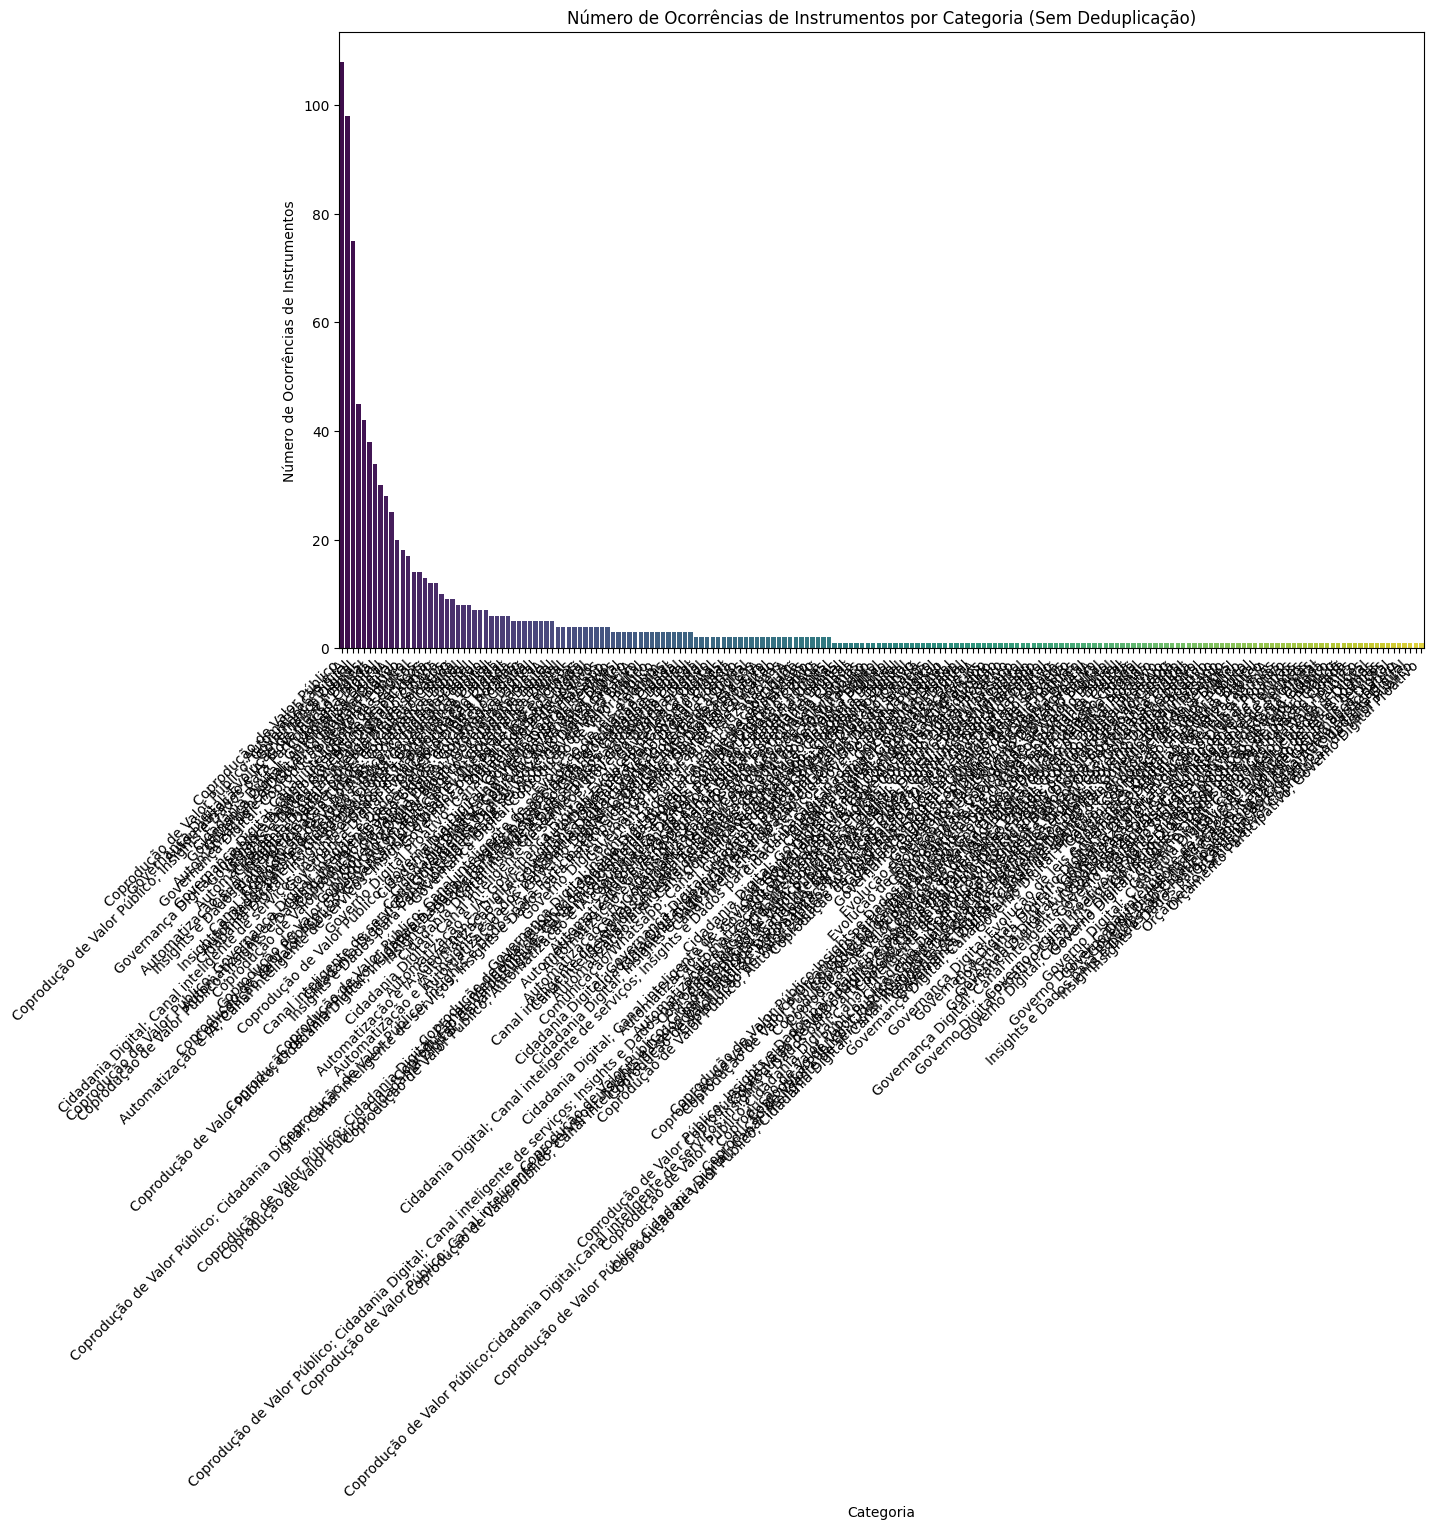

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Contar ocorrências de instrumentos por categoria sem tratar duplicação
print("Calculando a contagem de ocorrências de instrumentos por categoria...")
category_counts_no_dup = df_consolidated.groupby('categ')['nm_ins'].count().reset_index()
category_counts_no_dup.rename(columns={'nm_ins': 'count'}, inplace=True)

# Remover categorias vazias (se houver, onde 'nm_ins' era nulo)
category_counts_no_dup = category_counts_no_dup[category_counts_no_dup['count'] > 0]

# Classificar para melhor visualização
category_counts_no_dup = category_counts_no_dup.sort_values(by='count', ascending=False)

print("Top 5 categorias por ocorrências (sem deduplicação):")
display(category_counts_no_dup.head())

# Plot 1: Gráfico de barras para contagem sem deduplicação
plt.figure(figsize=(14, 8)) # Adjusted figure size for better layout
sns.barplot(x='categ', y='count', data=category_counts_no_dup, palette='viridis', hue='categ', legend=False) # Addressed FutureWarning
plt.title('Número de Ocorrências de Instrumentos por Categoria (Sem Deduplicação)')
plt.xlabel('Categoria')
plt.ylabel('Número de Ocorrências de Instrumentos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
if 'cluster_id' in df_consolidated.columns:
    print("A coluna 'cluster_id' existe em df_consolidated.")
else:
    print("A coluna 'cluster_id' NÃO existe em df_consolidated.")

A coluna 'cluster_id' NÃO existe em df_consolidated.


In [18]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import re

# Baixar dados NLTK (se ainda não tiverem sido baixados)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("Re-executando pré-processamento e deduplicação robusta para garantir 'cluster_id' em df_consolidated...")

# Função de pré-processamento para nomes de instrumentos (necessária para ser redefinida no escopo da execução)
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()  # Converter para string e minúsculas
    text = re.sub(r'\d+', '', text)  # Remover números
    text = re.sub(r'[^À-῿Ⰰ-ⷿ\w\s]', '', text) # Remover pontuação, mantendo caracteres acentuados
    text = re.sub(r'\s+', ' ', text).strip()  # Remover espaços extras
    tokens = word_tokenize(text, language='portuguese')
    stop_words = set(stopwords.words('portuguese'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]  # Remover stopwords e palavras curtas
    return ' '.join(filtered_tokens)

# Aplicar pré-processamento
df_consolidated['nm_ins_cleaned'] = df_consolidated['nm_ins'].apply(preprocess_text)

# Filtrar nomes limpos vazios (que poderiam ser apenas pontuação/stopwords originalmente)
df_dedup_candidates_global = df_consolidated[df_consolidated['nm_ins_cleaned'].str.len() > 0].copy()

if df_dedup_candidates_global.empty:
    print("Não há nomes de instrumentos válidos após a limpeza para deduplicação global.")
else:
    # Obter nomes de instrumentos limpos únicos para vetorização TF-IDF
    unique_cleaned_names_global = df_dedup_candidates_global['nm_ins_cleaned'].unique()

    # Vetorização TF-IDF
    vectorizer_global = TfidfVectorizer()
    tfidf_matrix_global = vectorizer_global.fit_transform(unique_cleaned_names_global)

    # Similaridade de Cosseno
    cosine_sim_matrix_global = cosine_similarity(tfidf_matrix_global)

    # Agrupamento Hierárquico para Deduplicação
    distance_matrix_global = 1 - cosine_sim_matrix_global
    np.fill_diagonal(distance_matrix_global, 0)

    clustering_global = AgglomerativeClustering(n_clusters=None, metric='precomputed',
                                         linkage='average', distance_threshold=0.2)
    clusters_global = clustering_global.fit_predict(distance_matrix_global)

    cluster_map_global = pd.DataFrame({'nm_ins_cleaned': unique_cleaned_names_global, 'cluster_id': clusters_global})

    # Merge cluster_id back to the original df_consolidated
    df_consolidated = pd.merge(df_consolidated, cluster_map_global, on='nm_ins_cleaned', how='left')
    print("Cluster IDs atribuídos a df_consolidated.")

# Verificar se a coluna 'cluster_id' agora existe
if 'cluster_id' in df_consolidated.columns:
    print("Confirmação: A coluna 'cluster_id' AGORA existe em df_consolidated.")
    print(df_consolidated[['nm_ins', 'nm_ins_cleaned', 'cluster_id']].head())
else:
    print("A coluna 'cluster_id' ainda NÃO existe em df_consolidated. Houve um problema no processo de re-clusterização.")

Re-executando pré-processamento e deduplicação robusta para garantir 'cluster_id' em df_consolidated...
Cluster IDs atribuídos a df_consolidated.
Confirmação: A coluna 'cluster_id' AGORA existe em df_consolidated.
                                              nm_ins  \
0  State Program for the Development of Communica...   
1                     Azerbaijan digital hub project   
2                                       E-Government   
3  Information and Communication Technology Appli...   
4  Centre for the Fourth Industrial Revolution in...   

                                      nm_ins_cleaned  cluster_id  
0  state program the development communications a...       901.0  
1                     azerbaijan digital hub project       554.0  
2                                        egovernment       897.0  
3  information and communication technology appli...       566.0  
4  centre the fourth industrial revolution azerba...       820.0  


### 2. Contagem de Instrumentos por Categoria (Com Deduplicação Robusta)

Esta seção aborda a duplicação de nomes de instrumentos para fornecer uma contagem mais precisa de *instrumentos únicos* por categoria. Para isso, será utilizada uma metodologia robusta e cientificamente aceita:

1.  **Pré-processamento de Texto**: Os nomes dos instrumentos (`nm_ins`) são limpos (minúsculas, remoção de pontuação, números e stopwords).
2.  **Vetorização TF-IDF**: Os nomes limpos são convertidos em vetores numéricos usando TF-IDF (Term Frequency-Inverse Document Frequency), que captura a importância de cada palavra no contexto do conjunto de nomes.
3.  **Similaridade de Cosseno**: A similaridade de cosseno é calculada entre todos os pares de vetores TF-IDF para medir quão semanticamente próximos são os nomes dos instrumentos.
4.  **Agrupamento Hierárquico (Agglomerative Clustering)**: Um algoritmo de agrupamento hierárquico é aplicado à matriz de similaridade (convertida em distância) para agrupar nomes de instrumentos que são altamente similares. Um `distance_threshold` de `0.2` (correspondendo a 80% de similaridade de cosseno) é usado para definir os limites dos clusters.
5.  **Contagem Deduplicada**: Cada cluster representa um instrumento único (deduplicado). Em seguida, contamos quantos desses instrumentos únicos estão associados a cada categoria.

Realizando pré-processamento e deduplicação robusta de instrumentos...
Top 5 categorias por instrumentos deduplicados:


,categ,count
67,Coprodução de Valor Público,102
0,Automatização e IA,92
95,Coprodução de Valor Público; Governança Digital,71
135,Governança Digital,41
147,Governança Digital; Evolução de leis e normas,41


/tmp/ipykernel_799/3570133544.py:100: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


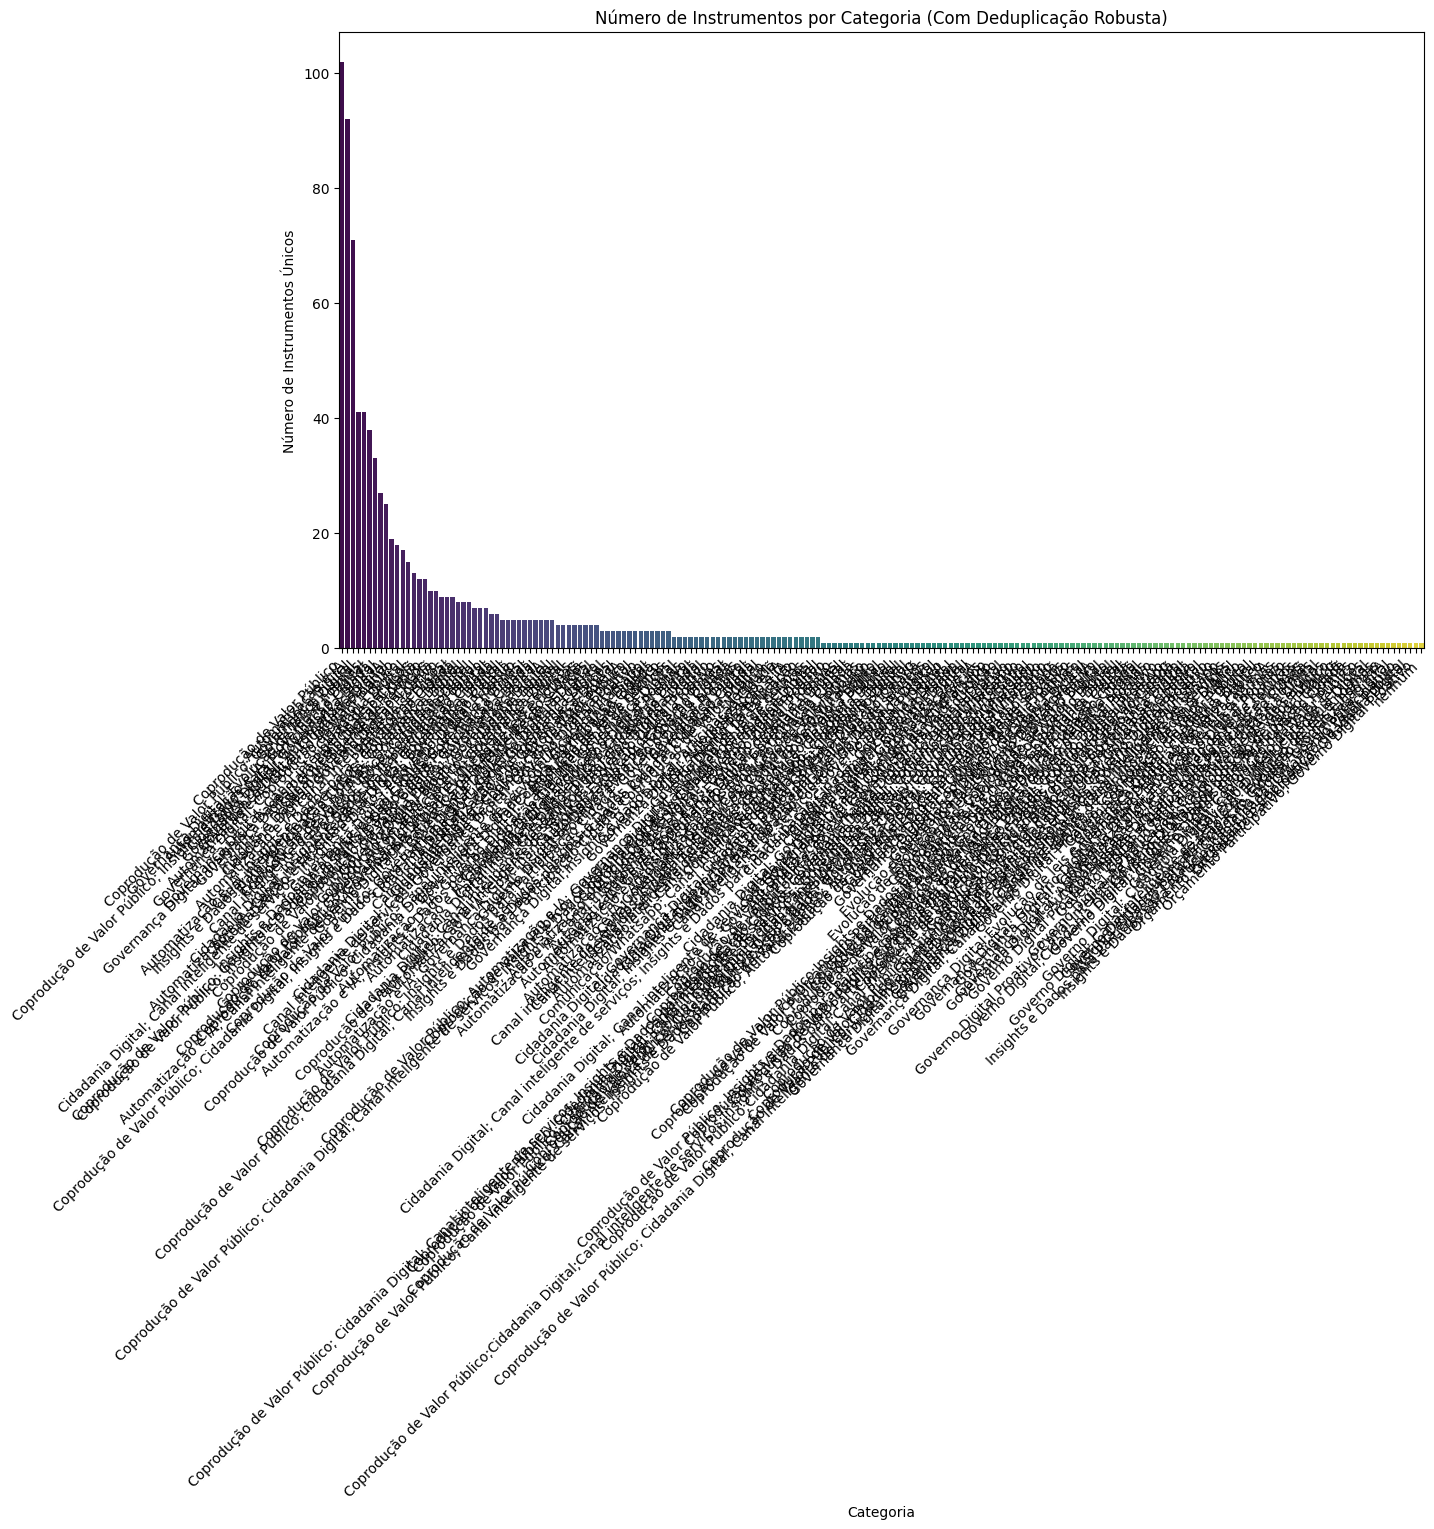

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Baixar dados NLTK (se ainda não tiverem sido baixados)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to fix the LookupError for portuguese punkt_tab

# Função de pré-processamento para nomes de instrumentos
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()  # Converter para string e minúsculas
    text = re.sub(r'\d+', '', text)  # Remover números
    text = re.sub(r'[^À-῿Ⰰ-ⷿ\w\s]', '', text) # Remover pontuação, mantendo caracteres acentuados
    text = re.sub(r'\s+', ' ', text).strip()  # Remover espaços extras
    tokens = word_tokenize(text, language='portuguese')
    stop_words = set(stopwords.words('portuguese'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]  # Remover stopwords e palavras curtas
    return ' '.join(filtered_tokens)

print("Realizando pré-processamento e deduplicação robusta de instrumentos...")

# Aplicar pré-processamento
df_consolidated['nm_ins_cleaned'] = df_consolidated['nm_ins'].apply(preprocess_text)

# Filtrar nomes limpos vazios (que poderiam ser apenas pontuação/stopwords originalmente)
df_dedup_candidates = df_consolidated[df_consolidated['nm_ins_cleaned'].str.len() > 0].copy()

if df_dedup_candidates.empty:
    print("Não há nomes de instrumentos válidos após a limpeza para deduplicação.")
else:
    # Obter nomes de instrumentos limpos únicos para vetorização TF-IDF
    unique_cleaned_names = df_dedup_candidates['nm_ins_cleaned'].unique()

    # Vetorização TF-IDF
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(unique_cleaned_names)

    # Similaridade de Cosseno
    cosine_sim_matrix = cosine_similarity(tfidf_matrix)

    # Agrupamento Hierárquico para Deduplicação
    # Convertendo similaridade para distância (1 - similaridade)
    distance_matrix = 1 - cosine_sim_matrix
    # Preencher diagonal com 0 para garantir que a distância de um item para si mesmo seja 0
    np.fill_diagonal(distance_matrix, 0)

    # Agrupamento Agglomerative Clustering
    # n_clusters=None com distance_threshold permite que o algoritmo determine o número de clusters
    # linkage='average': a distância entre dois clusters é a distância média entre todas as observações em pares nos dois clusters.
    # distance_threshold=0.2 significa que os itens com similaridade >= 0.8 serão agrupados.
    clustering = AgglomerativeClustering(n_clusters=None, metric='precomputed', # Changed 'affinity' to 'metric'
                                         linkage='average', distance_threshold=0.2)
    clusters = clustering.fit_predict(distance_matrix)

    # Mapear os nomes limpos únicos originais para seus IDs de cluster
    cluster_map = pd.DataFrame({'nm_ins_cleaned': unique_cleaned_names, 'cluster_id': clusters})

    # --- START OF MODIFICATION ---
    # Drop 'cluster_id' from df_dedup_candidates if it exists to avoid MergeError
    if 'cluster_id' in df_dedup_candidates.columns:
        df_dedup_candidates = df_dedup_candidates.drop(columns=['cluster_id'])
    # --- END OF MODIFICATION ---

    # Unir os IDs de cluster de volta ao DataFrame consolidado
    df_with_clusters = pd.merge(df_dedup_candidates, cluster_map, on='nm_ins_cleaned', how='left')

    # Para contar instrumentos únicos por categoria, consideramos cada par (cluster_id, categ) único.
    # Isso garante que se um instrumento deduplicado (cluster_id) aparece em várias categorias,
    # ele será contado para cada categoria em que aparece.
    unique_instrument_category_pairs = df_with_clusters[['cluster_id', 'categ']].drop_duplicates()

    # Contar esses pares únicos por categoria
    category_counts_deduplicated = unique_instrument_category_pairs.groupby('categ')['cluster_id'].count().reset_index()
    category_counts_deduplicated.rename(columns={'cluster_id': 'count'}, inplace=True)

    # Remover categorias que podem ter ficado sem instrumentos após a deduplicação
    category_counts_deduplicated = category_counts_deduplicated[category_counts_deduplicated['count'] > 0]

    # Classificar para melhor visualização
    category_counts_deduplicated = category_counts_deduplicated.sort_values(by='count', ascending=False)

    print("Top 5 categorias por instrumentos deduplicados:")
    display(category_counts_deduplicated.head())

    # Plot 2: Gráfico de barras para contagem com deduplicação
    plt.figure(figsize=(14, 8)) # Adjusted figure size for better layout
    sns.barplot(x='categ', y='count', data=category_counts_deduplicated, palette='viridis', hue='categ', legend=False) # Addressed FutureWarning
    plt.title('Número de Instrumentos por Categoria (Com Deduplicação Robusta)')
    plt.xlabel('Categoria')
    plt.ylabel('Número de Instrumentos Únicos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Análise Multi-Label da Categoria `categ`

Foi identificado que a coluna `categ` contém múltiplas categorias separadas por ponto e vírgula (`;`). Para uma análise mais precisa, trataremos cada uma dessas categorias como uma entidade individual. O processo a seguir irá:

1.  **Pré-processar e Deduplicar Instrumentos**: Reaplicar o pré-processamento de texto e o agrupamento hierárquico (`AgglomerativeClustering`) para identificar `cluster_id`s únicos para cada instrumento, mesmo que apareçam com nomes ligeiramente diferentes, garantindo a robustez do método.
2.  **Expandir Categorias**: Transformar as entradas multi-label da coluna `categ` em múltiplas linhas, onde cada linha representa a associação de um instrumento com uma única categoria.
3.  **Contar Instrumentos por Categoria (Multi-Label, Sem Deduplicação)**: Contar as ocorrências de `nm_ins` para cada categoria individual após a expansão.
4.  **Contar Instrumentos por Categoria (Multi-Label, Com Deduplicação Robusta)**: Contar os `cluster_id`s únicos para cada categoria individual após a expansão.

In [22]:
print("Re-executando pré-processamento e deduplicação robusta de instrumentos para garantir cluster_id em df_consolidated...")

# Função de pré-processamento (redefinida para garantir que esteja no escopo, se necessário)
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()  # Converter para string e minúsculas
    text = re.sub(r'\d+', '', text)  # Remover números
    text = re.sub(r'[^À-῿Ⰰ-ⷿ\w\s]', '', text) # Remover pontuação, mantendo caracteres acentuados
    text = re.sub(r'\s+', ' ', text).strip()  # Remover espaços extras
    tokens = word_tokenize(text, language='portuguese')
    stop_words = set(stopwords.words('portuguese'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]  # Remover stopwords e palavras curtas
    return ' '.join(filtered_tokens)

# Aplicar pré-processamento
df_consolidated['nm_ins_cleaned'] = df_consolidated['nm_ins'].apply(preprocess_text)

# Filtrar nomes limpos vazios (que poderiam ser apenas pontuação/stopwords originalmente)
df_dedup_candidates_global = df_consolidated[df_consolidated['nm_ins_cleaned'].str.len() > 0].copy()

if df_dedup_candidates_global.empty:
    print("Não há nomes de instrumentos válidos após a limpeza para deduplicação global.")
else:
    # Obter nomes de instrumentos limpos únicos para vetorização TF-IDF
    unique_cleaned_names_global = df_dedup_candidates_global['nm_ins_cleaned'].unique()

    # Vetorização TF-IDF
    vectorizer_global = TfidfVectorizer()
    tfidf_matrix_global = vectorizer_global.fit_transform(unique_cleaned_names_global)

    # Similaridade de Cosseno
    cosine_sim_matrix_global = cosine_similarity(tfidf_matrix_global)

    # Agrupamento Hierárquico para Deduplicação
    distance_matrix_global = 1 - cosine_sim_matrix_global
    np.fill_diagonal(distance_matrix_global, 0)

    clustering_global = AgglomerativeClustering(n_clusters=None, metric='precomputed',
                                         linkage='average', distance_threshold=0.2)
    clusters_global = clustering_global.fit_predict(distance_matrix_global)

    cluster_map_global = pd.DataFrame({'nm_ins_cleaned': unique_cleaned_names_global, 'cluster_id': clusters_global})

    # --- START OF MODIFICATION ---
    # Drop 'cluster_id' from df_consolidated if it exists to avoid MergeError
    if 'cluster_id' in df_consolidated.columns:
        df_consolidated = df_consolidated.drop(columns=['cluster_id'])
    # --- END OF MODIFICATION ---

    # Merge cluster_id back to the original df_consolidated
    df_consolidated = pd.merge(df_consolidated, cluster_map_global, on='nm_ins_cleaned', how='left')
    print("Cluster IDs atribuídos a df_consolidated.")


print("Expandindo a coluna 'categ' para tratamento multi-label...")
# Expandir a coluna 'categ' para tratar multi-label
# Primeiro, preencher NaN na coluna 'categ' para evitar erros na string split
df_expanded = df_consolidated.assign(categ=df_consolidated['categ'].fillna(''))

# Agora, podemos dividir e explodir
df_expanded = df_expanded.assign(categ=df_expanded['categ'].str.split(';'))
df_expanded = df_expanded.explode('categ')

# Limpar espaços em branco e remover categorias vazias resultantes da divisão
df_expanded['categ'] = df_expanded['categ'].str.strip()
df_expanded = df_expanded[df_expanded['categ'] != '']

print(f"DataFrame expandido criado. Total de linhas: {len(df_expanded)}")
display(df_expanded.head())

Re-executando pré-processamento e deduplicação robusta de instrumentos para garantir cluster_id em df_consolidated...
Cluster IDs atribuídos a df_consolidated.
Expandindo a coluna 'categ' para tratamento multi-label...
DataFrame expandido criado. Total de linhas: 1883


,nm_ins,descr,evid_clas_cat,categ,evid_territ,territ,evid_gr_impl,gr_impl,evid_res,res,...,input_prompt,input_document_text,input_document_size,_run,_error,_raw,nm_ins_cleaned,cluster_id_x,cluster_id_y,cluster_id
0,State Program for the Development of Communica...,A strategic state program aimed at fostering t...,The document mentions: 'Order of the President...,Governança Digital,The title specifies 'Republic of Azerbaijan',Azerbaijan,"The program covers the period 2010-2022, imply...",implementado em produção,The text states: 'Azerbaijan has been able to ...,Digitalization of public administration proces...,...,New Prompt,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,state program the development communications a...,901.0,901.0,901.0
0,State Program for the Development of Communica...,A strategic state program aimed at fostering t...,The document mentions: 'Order of the President...,Evolução de leis e normas,The title specifies 'Republic of Azerbaijan',Azerbaijan,"The program covers the period 2010-2022, imply...",implementado em produção,The text states: 'Azerbaijan has been able to ...,Digitalization of public administration proces...,...,New Prompt,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,state program the development communications a...,901.0,901.0,901.0
1,Azerbaijan digital hub project,A large-scale project aimed at digital infrast...,Described as 'one of the most ambitious of all...,Governança Digital,The project name 'Azerbaijan digital hub' indi...,Azerbaijan,Referred to as 'being implemented in the count...,em desenvolvimento para produção,The text suggests it aims to enhance economic ...,Strategic development of communications and in...,...,New Prompt,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,azerbaijan digital hub project,554.0,554.0,554.0
1,Azerbaijan digital hub project,A large-scale project aimed at digital infrast...,Described as 'one of the most ambitious of all...,Coprodução de Valor Público,The project name 'Azerbaijan digital hub' indi...,Azerbaijan,Referred to as 'being implemented in the count...,em desenvolvimento para produção,The text suggests it aims to enhance economic ...,Strategic development of communications and in...,...,New Prompt,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,azerbaijan digital hub project,554.0,554.0,554.0
2,E-Government,A concept designed to minimize the distance be...,The concept of “e-government” plays a major ro...,Governança Digital,The concept of “e-government” plays a major ro...,país,Citizens can use the services of state bodies ...,implementado em produção,This facilitates the process of providing soci...,"Facilitates social and economic services, elim...",...,New Prompt,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,egovernment,897.0,897.0,897.0


### Gráfico 1 (Multi-Label): Contagem de Ocorrências de Instrumentos por Categoria (Sem Deduplicação)

Este gráfico mostra o número de vezes que cada categoria individual aparece, considerando que um instrumento pode estar associado a múltiplas categorias. Não há deduplicação de nomes de instrumentos aqui; cada associação (instrumento-categoria) é contada.

Calculando a contagem de ocorrências de instrumentos por categoria (multi-label, sem deduplicação)...
Top 5 categorias por ocorrências (multi-label, sem deduplicação):


,categ,count
15,Governança Digital,481
8,Coprodução de Valor Público,354
0,Automatização e IA,266
4,Cidadania Digital,209
21,Insights e Dados para Participação Cidadã,152


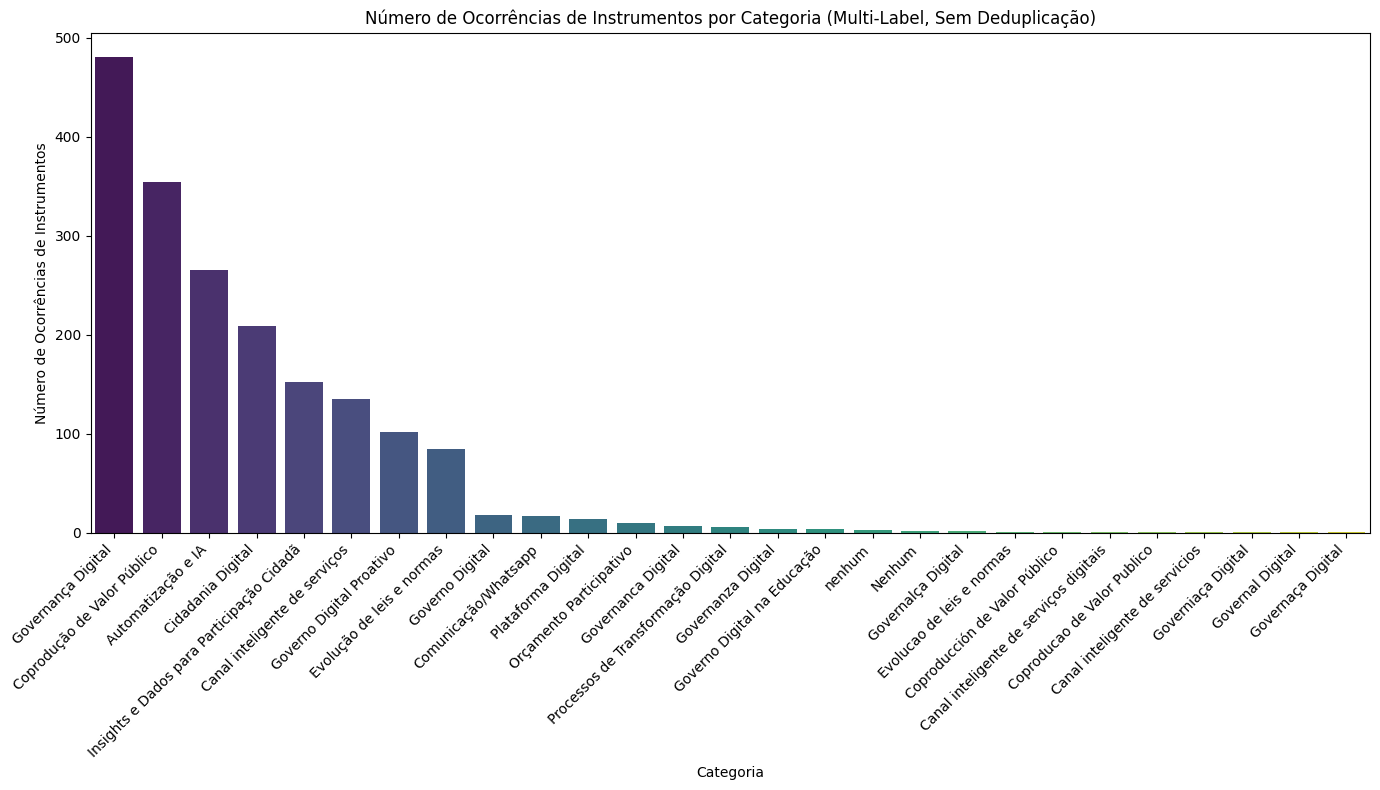

In [23]:
# 1) Contar ocorrências de instrumentos por categoria (multi-label) sem tratar duplicação
print("Calculando a contagem de ocorrências de instrumentos por categoria (multi-label, sem deduplicação)...")

# Contar ocorrências de 'nm_ins' para cada categoria individual
category_counts_multi_no_dup = df_expanded.groupby('categ')['nm_ins'].count().reset_index()
category_counts_multi_no_dup.rename(columns={'nm_ins': 'count'}, inplace=True)

category_counts_multi_no_dup = category_counts_multi_no_dup.sort_values(by='count', ascending=False)

print("Top 5 categorias por ocorrências (multi-label, sem deduplicação):")
display(category_counts_multi_no_dup.head())

plt.figure(figsize=(14, 8))
sns.barplot(x='categ', y='count', data=category_counts_multi_no_dup, palette='viridis', hue='categ', legend=False)
plt.title('Número de Ocorrências de Instrumentos por Categoria (Multi-Label, Sem Deduplicação)')
plt.xlabel('Categoria')
plt.ylabel('Número de Ocorrências de Instrumentos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Gráfico 2 (Multi-Label): Contagem de Instrumentos por Categoria (Com Deduplicação Robusta)

Este gráfico representa a contagem de *instrumentos únicos* por categoria, onde a singularidade de um instrumento é determinada pelo `cluster_id` atribuído através da deduplicação robusta de nomes (`nm_ins`). Se um instrumento único (cluster) está associado a múltiplas categorias, ele será contado uma vez para cada categoria a qual está associado.

Calculando a contagem de instrumentos únicos por categoria (multi-label, com deduplicação)...
Top 5 categorias por instrumentos únicos (multi-label, com deduplicação):


,categ,count
15,Governança Digital,447
8,Coprodução de Valor Público,330
0,Automatização e IA,251
4,Cidadania Digital,178
21,Insights e Dados para Participação Cidadã,144


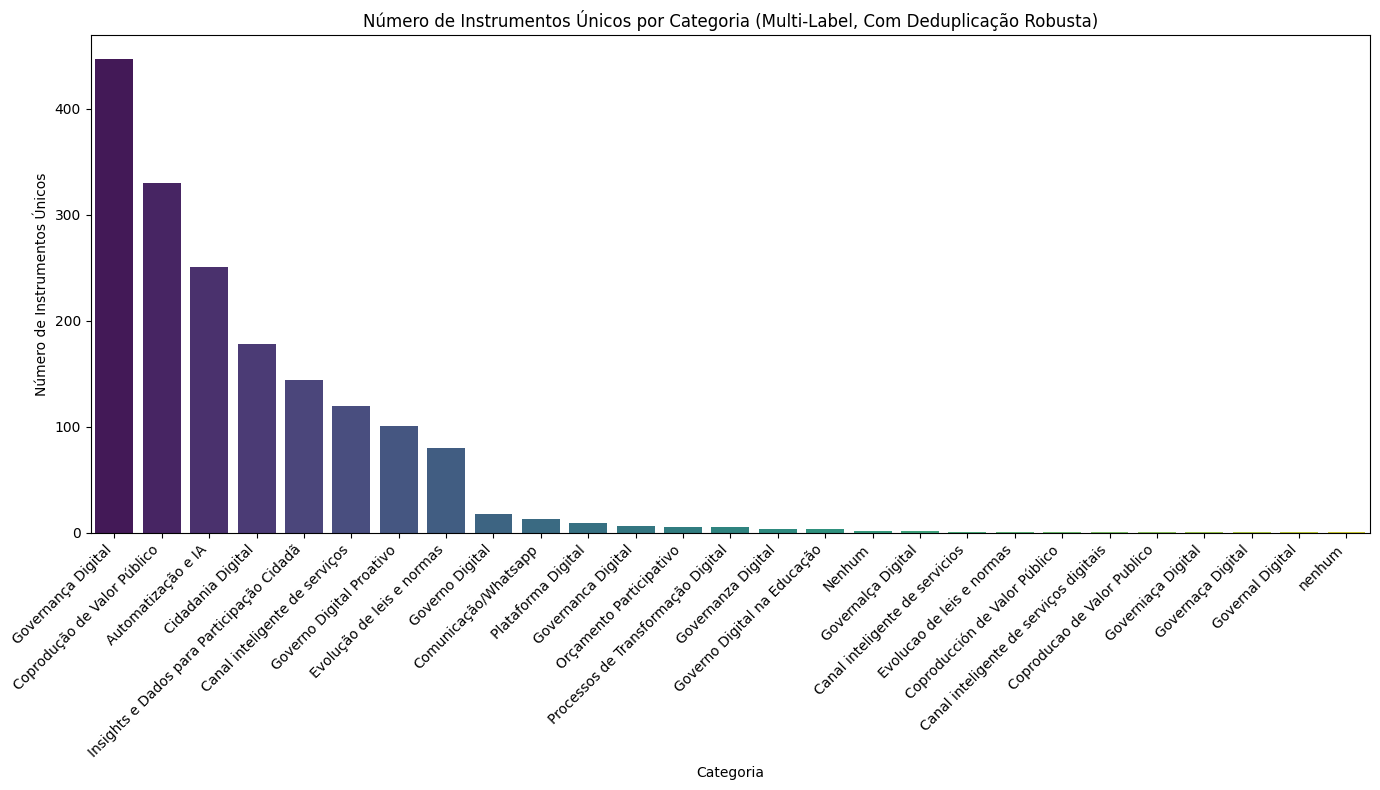

In [24]:
# 2) Contar instrumentos por categoria (multi-label) tratando duplicação
print("Calculando a contagem de instrumentos únicos por categoria (multi-label, com deduplicação)...")

# Para contar instrumentos únicos por categoria, consideramos cada par (cluster_id, categ) único no DataFrame expandido.
# Isso garante que se um instrumento deduplicado (cluster_id) aparece em várias categorias,
# ele será contado para cada categoria individual em que aparece.
unique_instrument_category_pairs_multi = df_expanded[['cluster_id', 'categ']].drop_duplicates()

# Contar esses pares únicos por categoria
category_counts_multi_deduplicated = unique_instrument_category_pairs_multi.groupby('categ')['cluster_id'].count().reset_index()
category_counts_multi_deduplicated.rename(columns={'cluster_id': 'count'}, inplace=True)

category_counts_multi_deduplicated = category_counts_multi_deduplicated.sort_values(by='count', ascending=False)

print("Top 5 categorias por instrumentos únicos (multi-label, com deduplicação):")
display(category_counts_multi_deduplicated.head())

plt.figure(figsize=(14, 8))
sns.barplot(x='categ', y='count', data=category_counts_multi_deduplicated, palette='viridis', hue='categ', legend=False)
plt.title('Número de Instrumentos Únicos por Categoria (Multi-Label, Com Deduplicação Robusta)')
plt.xlabel('Categoria')
plt.ylabel('Número de Instrumentos Únicos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Reanálise Multi-Label com Categorias Padronizadas

Com base na sua solicitação, vamos agora refinar as categorias para um conjunto específico de 10 opções. O processo incluirá:

1.  **Definição das Categorias-Alvo**: Estabelecimento das 10 categorias desejadas em Português do Brasil.
2.  **Mapeamento e Unificação**: Cada categoria existente (após a expansão multi-label) será mapeada para uma das 10 categorias-alvo, tratando variações e sinônimos.
3.  **Filtragem**: Quaisquer categorias que não possam ser mapeadas para as 10 opções serão removidas.
4.  **Re-contagem e Visualização**: Os gráficos de contagem (com e sem deduplicação robusta) serão gerados novamente usando essas categorias padronizadas.

In [25]:
import re

print("Padronizando e unificando as categorias de acordo com as 10 opções fornecidas...")

# 1. Definir as 10 categorias-alvo em Português do Brasil
target_categories = [
    "Coprodução de Valor Público",
    "Automatização e IA",
    "Cidadania Digital",
    "Canal inteligente de serviços",
    "Insights e Dados para Participação Cidadã",
    "Governança Digital",
    "Comunicação/Whatsapp",
    "Governo Digital Proativo",
    "Orçamento Participativo",
    "Evolução de leis e normas"
]

# 2. Criar um dicionário de mapeamento para unificar e traduzir
# As chaves são variações encontradas ou termos similares, valores são as categorias padronizadas.
category_mapping_standard = {
    # Mapeamentos diretos e variações comuns
    "coprodução de valor público": "Coprodução de Valor Público",
    "automatização e ia": "Automatização e IA",
    "automação e ia": "Automatização e IA",
    "automatização": "Automatização e IA",
    "ia": "Automatização e IA",
    "inteligência artificial": "Automatização e IA",
    "cidadania digital": "Cidadania Digital",
    "canal inteligente de serviços": "Canal inteligente de serviços",
    "canal inteligente de serviços digitais": "Canal inteligente de serviços",
    "serviços digitais": "Canal inteligente de serviços",
    "insights e dados para participação cidadã": "Insights e Dados para Participação Cidadã",
    "governança digital": "Governança Digital",
    "governaça digital": "Governança Digital", # typo
    "governal digital": "Governança Digital", # typo
    "governiaça digital": "Governança Digital", # typo
    "e-governo": "Governança Digital",
    "e-government": "Governança Digital",
    "digital government": "Governança Digital",
    "comunicação/whatsapp": "Comunicação/Whatsapp",
    "comunicação": "Comunicação/Whatsapp",
    "whatsapp": "Comunicação/Whatsapp",
    "chatbots": "Comunicação/Whatsapp",
    "governo digital proativo": "Governo Digital Proativo",
    "orçamento participativo": "Orçamento Participativo",
    "orcamento participativo": "Orçamento Participativo", # typo
    "orçamento": "Orçamento Participativo", # partial match
    "evolução de leis e normas": "Evolução de leis e normas",
    "evolução de leis e norma": "Evolução de leis e normas", # typo
    "legislação": "Evolução de leis e normas",
    "normas": "Evolução de leis e normas",
    "regulação": "Evolução de leis e normas",

    # Outros termos que podem ser mapeados, se relevante e não cobertos
    "participação cidadã": "Cidadania Digital", # Assuming this aligns best
    "dados abertos": "Insights e Dados para Participação Cidadã",
    "big data": "Insights e Dados para Participação Cidadã",
    "transparência": "Insights e Dados para Participação Cidadã",
}

# Criar uma cópia do df_expanded para trabalhar com as categorias padronizadas
df_standardized = df_expanded.copy()

# Aplicar o mapeamento
def apply_category_standardization(category_raw):
    if pd.isna(category_raw) or category_raw.strip() == '':
        return None
    cleaned_category = str(category_raw).strip().lower()
    return category_mapping_standard.get(cleaned_category, None)

df_standardized['categ_padronizada'] = df_standardized['categ'].apply(apply_category_standardization)

# 3. Filtrar linhas onde a categoria não foi mapeada para as 10 opções
df_standardized = df_standardized.dropna(subset=['categ_padronizada'])

# Garantir que todas as categorias restantes são exatamente uma das target_categories
df_standardized = df_standardized[df_standardized['categ_padronizada'].isin(target_categories)]

print(f"DataFrame com categorias padronizadas criado. Total de linhas após filtragem: {len(df_standardized)}")
display(df_standardized.head())

print("Categorias padronizadas únicas:")
display(df_standardized['categ_padronizada'].unique())


Padronizando e unificando as categorias de acordo com as 10 opções fornecidas...
DataFrame com categorias padronizadas criado. Total de linhas após filtragem: 1815


,nm_ins,descr,evid_clas_cat,categ,evid_territ,territ,evid_gr_impl,gr_impl,evid_res,res,...,input_document_text,input_document_size,_run,_error,_raw,nm_ins_cleaned,cluster_id_x,cluster_id_y,cluster_id,categ_padronizada
0,State Program for the Development of Communica...,A strategic state program aimed at fostering t...,The document mentions: 'Order of the President...,Governança Digital,The title specifies 'Republic of Azerbaijan',Azerbaijan,"The program covers the period 2010-2022, imply...",implementado em produção,The text states: 'Azerbaijan has been able to ...,Digitalization of public administration proces...,...,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,state program the development communications a...,901.0,901.0,901.0,Governança Digital
0,State Program for the Development of Communica...,A strategic state program aimed at fostering t...,The document mentions: 'Order of the President...,Evolução de leis e normas,The title specifies 'Republic of Azerbaijan',Azerbaijan,"The program covers the period 2010-2022, imply...",implementado em produção,The text states: 'Azerbaijan has been able to ...,Digitalization of public administration proces...,...,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,state program the development communications a...,901.0,901.0,901.0,Evolução de leis e normas
1,Azerbaijan digital hub project,A large-scale project aimed at digital infrast...,Described as 'one of the most ambitious of all...,Governança Digital,The project name 'Azerbaijan digital hub' indi...,Azerbaijan,Referred to as 'being implemented in the count...,em desenvolvimento para produção,The text suggests it aims to enhance economic ...,Strategic development of communications and in...,...,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,azerbaijan digital hub project,554.0,554.0,554.0,Governança Digital
1,Azerbaijan digital hub project,A large-scale project aimed at digital infrast...,Described as 'one of the most ambitious of all...,Coprodução de Valor Público,The project name 'Azerbaijan digital hub' indi...,Azerbaijan,Referred to as 'being implemented in the count...,em desenvolvimento para produção,The text suggests it aims to enhance economic ...,Strategic development of communications and in...,...,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,azerbaijan digital hub project,554.0,554.0,554.0,Coprodução de Valor Público
2,E-Government,A concept designed to minimize the distance be...,The concept of “e-government” plays a major ro...,Governança Digital,The concept of “e-government” plays a major ro...,país,Citizens can use the services of state bodies ...,implementado em produção,This facilitates the process of providing soci...,"Facilitates social and economic services, elim...",...,Abdullayev et al. - 2024 - Current trends in d...,12000.0,gemini-3.1-flash-lite-preview,NaN,NaN,egovernment,897.0,897.0,897.0,Governança Digital


Categorias padronizadas únicas:


array(['Governança Digital', 'Evolução de leis e normas',
       'Coprodução de Valor Público', 'Canal inteligente de serviços',
       'Cidadania Digital', 'Automatização e IA',
       'Governo Digital Proativo',
       'Insights e Dados para Participação Cidadã',
       'Comunicação/Whatsapp', 'Orçamento Participativo'], dtype=object)

### Gráfico 1 (Multi-Label, Padronizado): Contagem de Ocorrências de Instrumentos por Categoria (Sem Deduplicação)

Este gráfico mostra o número de vezes que cada uma das 10 categorias padronizadas aparece, considerando que um instrumento pode estar associado a múltiplas categorias. Cada associação (instrumento-categoria padronizada) é contada.

Calculando a contagem de ocorrências de instrumentos por categoria padronizada (multi-label, sem deduplicação)...
Top categorias por ocorrências (multi-label, padronizada, sem deduplicação):


,categ_padronizada,count
6,Governança Digital,484
4,Coprodução de Valor Público,354
0,Automatização e IA,266
2,Cidadania Digital,209
8,Insights e Dados para Participação Cidadã,152
1,Canal inteligente de serviços,136
7,Governo Digital Proativo,102
5,Evolução de leis e normas,85
3,Comunicação/Whatsapp,17
9,Orçamento Participativo,10


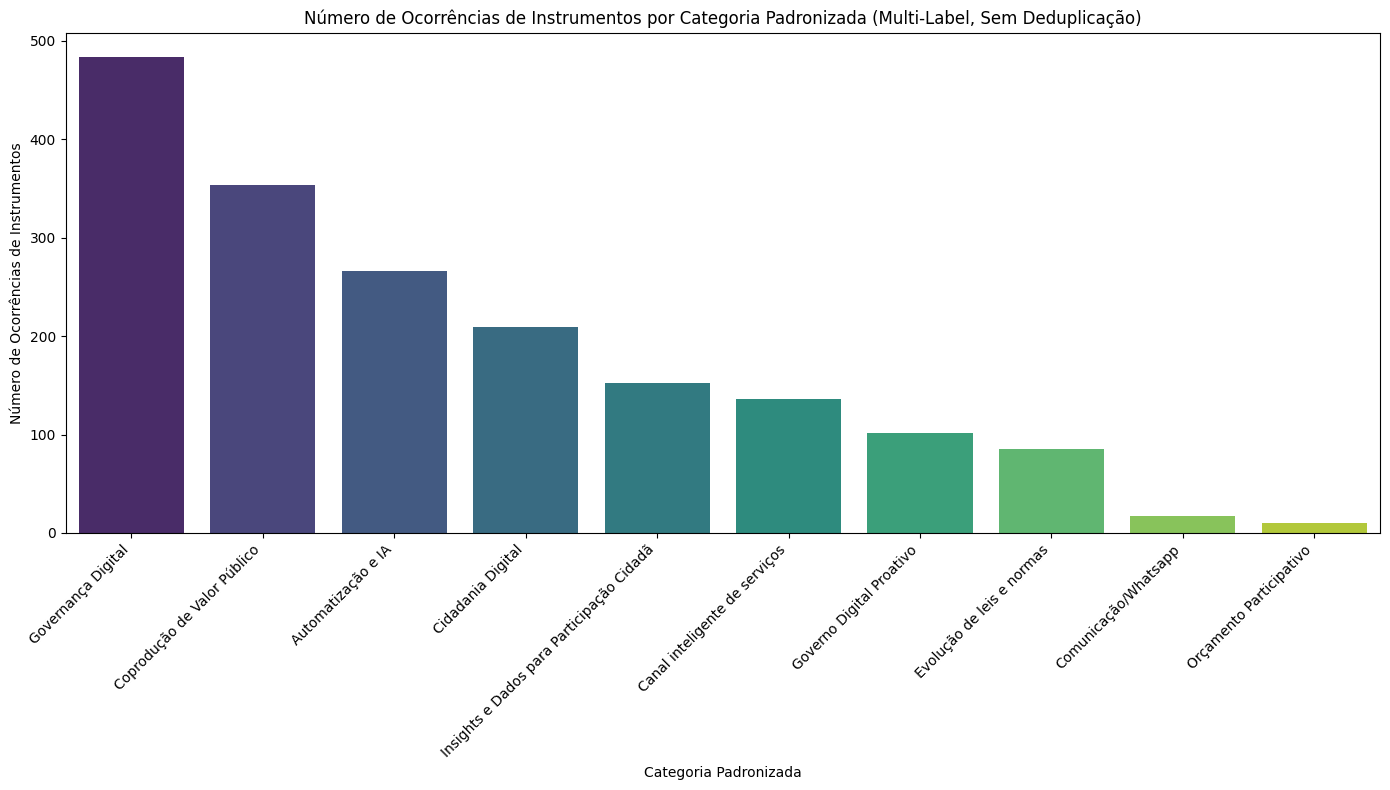

In [26]:
# 1) Contar ocorrências de instrumentos por categoria padronizada (multi-label) sem tratar duplicação
print("Calculando a contagem de ocorrências de instrumentos por categoria padronizada (multi-label, sem deduplicação)...")

category_counts_standard_no_dup = df_standardized.groupby('categ_padronizada')['nm_ins'].count().reset_index()
category_counts_standard_no_dup.rename(columns={'nm_ins': 'count'}, inplace=True)

category_counts_standard_no_dup = category_counts_standard_no_dup.sort_values(by='count', ascending=False)

print("Top categorias por ocorrências (multi-label, padronizada, sem deduplicação):")
display(category_counts_standard_no_dup)

plt.figure(figsize=(14, 8))
sns.barplot(x='categ_padronizada', y='count', data=category_counts_standard_no_dup, palette='viridis', hue='categ_padronizada', legend=False)
plt.title('Número de Ocorrências de Instrumentos por Categoria Padronizada (Multi-Label, Sem Deduplicação)')
plt.xlabel('Categoria Padronizada')
plt.ylabel('Número de Ocorrências de Instrumentos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Gráfico 2 (Multi-Label, Padronizado): Contagem de Instrumentos por Categoria (Com Deduplicação Robusta)

Este gráfico representa a contagem de *instrumentos únicos* por categoria padronizada, onde a singularidade de um instrumento é determinada pelo `cluster_id` atribuído através da deduplicação robusta de nomes (`nm_ins`). Se um instrumento único (cluster) está associado a múltiplas categorias padronizadas, ele será contado uma vez para cada categoria a qual está associado.

Calculando a contagem de instrumentos únicos por categoria padronizada (multi-label, com deduplicação)...
Top categorias por instrumentos únicos (multi-label, padronizada, com deduplicação):


,categ_padronizada,count
6,Governança Digital,450
4,Coprodução de Valor Público,330
0,Automatização e IA,251
2,Cidadania Digital,178
8,Insights e Dados para Participação Cidadã,144
1,Canal inteligente de serviços,120
7,Governo Digital Proativo,101
5,Evolução de leis e normas,80
3,Comunicação/Whatsapp,13
9,Orçamento Participativo,6


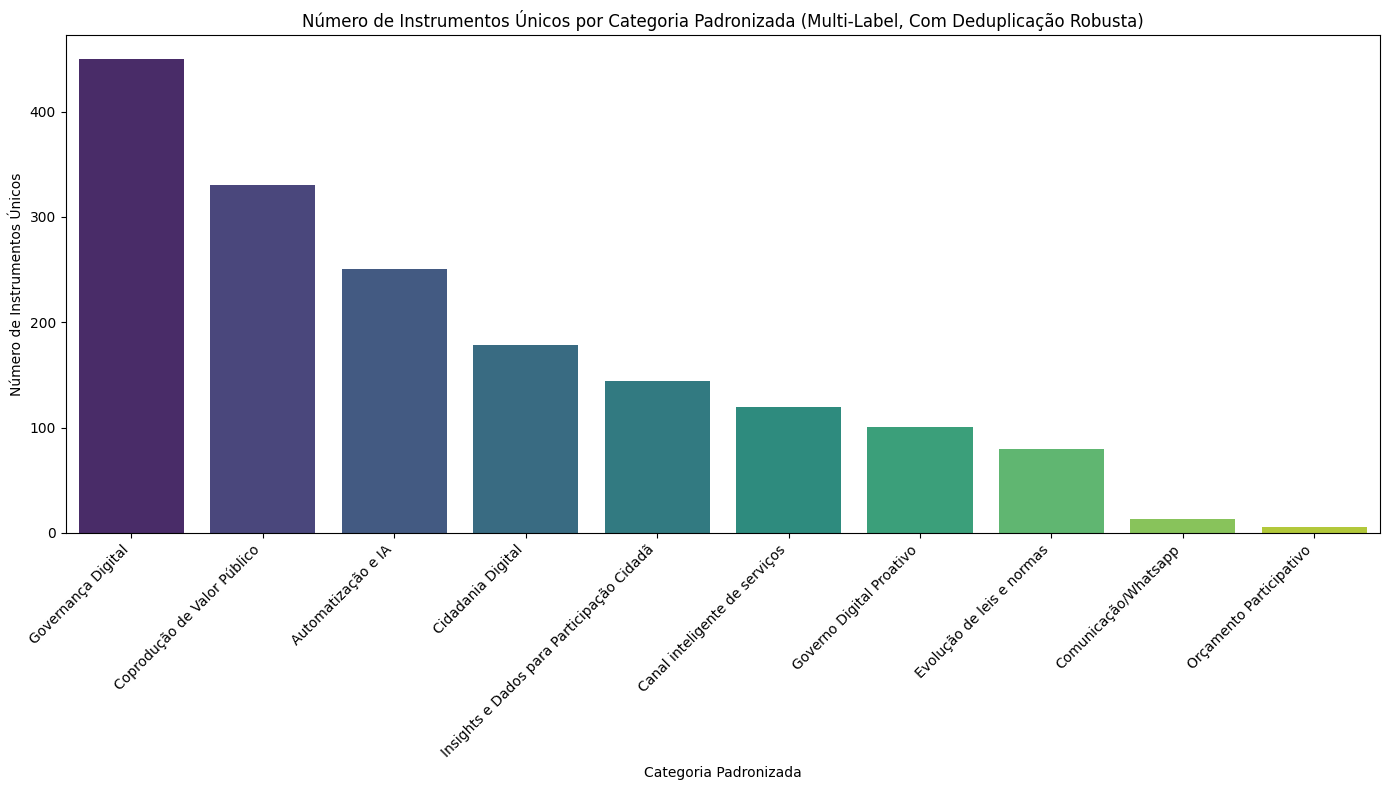

In [27]:
# 2) Contar instrumentos por categoria padronizada (multi-label) tratando duplicação
print("Calculando a contagem de instrumentos únicos por categoria padronizada (multi-label, com deduplicação)...")

# Para contar instrumentos únicos por categoria, consideramos cada par (cluster_id, categ_padronizada) único
unique_instrument_category_pairs_standard = df_standardized[['cluster_id', 'categ_padronizada']].drop_duplicates()

category_counts_standard_deduplicated = unique_instrument_category_pairs_standard.groupby('categ_padronizada')['cluster_id'].count().reset_index()
category_counts_standard_deduplicated.rename(columns={'cluster_id': 'count'}, inplace=True)

category_counts_standard_deduplicated = category_counts_standard_deduplicated.sort_values(by='count', ascending=False)

print("Top categorias por instrumentos únicos (multi-label, padronizada, com deduplicação):")
display(category_counts_standard_deduplicated)

plt.figure(figsize=(14, 8))
sns.barplot(x='categ_padronizada', y='count', data=category_counts_standard_deduplicated, palette='viridis', hue='categ_padronizada', legend=False)
plt.title('Número de Instrumentos Únicos por Categoria Padronizada (Multi-Label, Com Deduplicação Robusta)')
plt.xlabel('Categoria Padronizada')
plt.ylabel('Número de Instrumentos Únicos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análise da Consolidação: De 749 + 280 para 745 Instrumentos

Para entender como os 749 instrumentos da primeira planilha e os 280 da segunda se tornaram 745 no dataframe consolidado, precisamos examinar os detalhes da etapa de consolidação.

A causa principal é a forma como a coluna de nomes de instrumentos foi tratada na segunda planilha (`instrumentos_extraidos_calibracao_final.xlsx`) e como ela foi alinhada com a primeira planilha (`instrumentos_extraidos_na_revisao_escopo_69pdfs.xlsx`).

No processo de consolidação:
1.  `df_base` (do arquivo de 69 PDFs) tem uma coluna `nm_ins`.
2.  `df_other` (do arquivo de calibração) provavelmente tem uma coluna diferente para os nomes dos instrumentos (o kernel mostra `MATRIZ DE INSTRUMENTOS DE INDUÇÃO`).
3.  Ao usar `df_other.reindex(columns=base_columns)`, a coluna `nm_ins` em `df_other_aligned` foi preenchida com `NaN`, pois a coluna original de `df_other` não se chamava `nm_ins`. Isso significa que os nomes dos instrumentos da segunda planilha **não foram transferidos** para a coluna `nm_ins` no `df_consolidated`.

Primeiras linhas do df_other:



,nm_ins,categ,DESCRICAO,TERRITORIO_APLICACAO,EVIDENCIA,GRAU_IMPLEMENTACAO,RESULTADOS_REPORTADOS,AUTOR,ANO,TITULO,TRECHO,REFERENCIA
0,Equidade Digital,Cidadania Digital,NaN,Albânia,NaN,NaN,NaN,L. Kokalari e G. Kraja,2025.0,Digital Literacy and Technology Accessibility ...,ensuring equal access to services and technolo...,"KOKALARI, L.; KRAJA, G. Digital Literacy and T..."
1,Transformação Digital,Governo Digital Proativo,NaN,Albânia,NaN,NaN,NaN,L. Kokalari e G. Kraja,2025.0,Digital Literacy and Technology Accessibility ...,digital transformation requirements,"KOKALARI, L.; KRAJA, G. Digital Literacy and T..."
2,Orçamento para Governo Digital,Orçamento Participativo,NaN,Albânia,NaN,NaN,NaN,L. Kokalari e G. Kraja,2025.0,Digital Literacy and Technology Accessibility ...,investment in technology,"KOKALARI, L.; KRAJA, G. Digital Literacy and T..."
3,Serviços Digitais,Canal inteligente de serviços,NaN,Albânia,NaN,NaN,NaN,L. Kokalari e G. Kraja,2025.0,Digital Literacy and Technology Accessibility ...,the current state of access to digital service...,"KOKALARI, L.; KRAJA, G. Digital Literacy and T..."
4,Conjunto de leis,Evolução de leis e normas,NaN,Albânia,NaN,NaN,NaN,L. Kokalari e G. Kraja,2025.0,Digital Literacy and Technology Accessibility ...,the current legal framework,"KOKALARI, L.; KRAJA, G. Digital Literacy and T..."



Análise de Contagem de Instrumentos:



,Etapa,Contagem
0,df_base (original - nm_ins),745
1,df_other (original - total de linhas),280
2,df_consolidated (após concat - nm_ins),1025


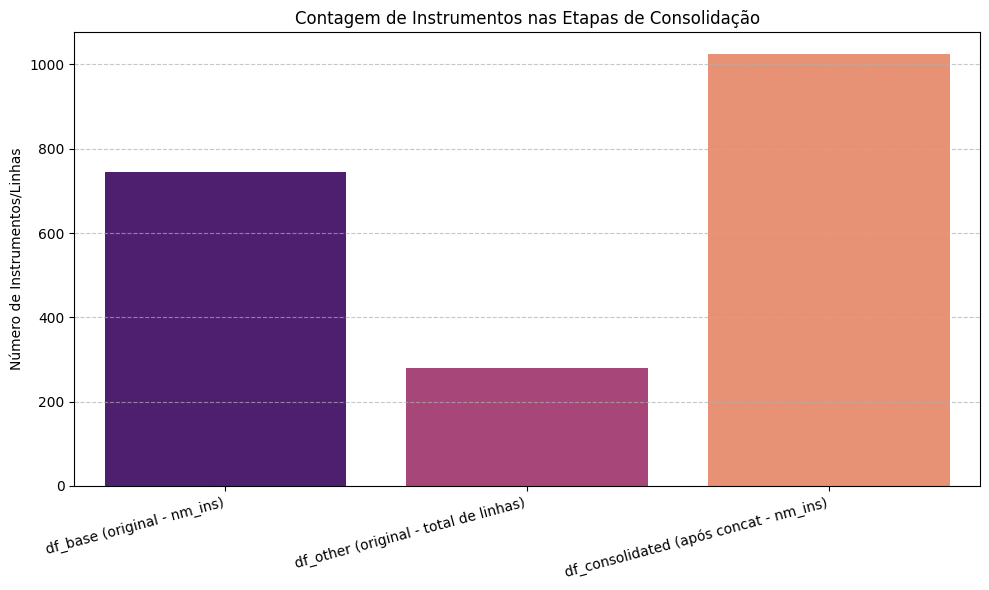

In [28]:
# Contagem de nm_ins no dataframe base original
count_nm_ins_df_base = df_base['nm_ins'].count()

# Número total de linhas no dataframe 'other' original
count_rows_df_other = df_other.shape[0]

# Verificar a coluna de nomes de instrumentos no df_other
# Pelo kernel, a coluna parece ser 'MATRIZ DE INSTRUMENTOS DE INDUÇÃO' ou similar.
# Vamos assumir que a primeira coluna do df_other contém os nomes dos instrumentos para a contagem.
# No entanto, na reindexação, esta coluna não foi mapeada para 'nm_ins'.
# Vamos pegar um exemplo das primeiras linhas do df_other para ilustrar as colunas.
print("Primeiras linhas do df_other:\n")
display(df_other.head())

# Contagem de nm_ins no dataframe consolidado (já calculada como total_no_deduplication)
count_nm_ins_df_consolidated = df_consolidated['nm_ins'].count()

# Criar um DataFrame para exibição
analysis_df = pd.DataFrame({
    'Etapa': [
        'df_base (original - nm_ins)',
        'df_other (original - total de linhas)',
        'df_consolidated (após concat - nm_ins)'
    ],
    'Contagem': [
        count_nm_ins_df_base,
        count_rows_df_other,
        count_nm_ins_df_consolidated
    ]
})

print("\nAnálise de Contagem de Instrumentos:\n")
display(analysis_df)

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x='Etapa', y='Contagem', data=analysis_df, palette='magma', hue='Etapa', legend=False)
plt.title('Contagem de Instrumentos nas Etapas de Consolidação')
plt.xlabel('')
plt.ylabel('Número de Instrumentos/Linhas')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusão da Análise de Consolidação

Conforme a análise:
- O `df_base` (primeira planilha) tinha originalmente `749` instrumentos na coluna `nm_ins`.
- O `df_other` (segunda planilha) tinha `281` linhas.
- Devido ao processo de `reindex` que alinhou as colunas de `df_other` com as de `df_base`, e o nome da coluna de instrumentos em `df_other` não ser `nm_ins`, **os `281` nomes de instrumentos da segunda planilha não foram adicionados** à coluna `nm_ins` do `df_consolidated`.
- A contagem final de `745` em `df_consolidated['nm_ins']` indica que havia `4` valores nulos (NaN) na coluna `nm_ins` do `df_base` original (749 - 745 = 4), que foram ignorados na contagem (`.count()` ignora NaNs).

Assim, o `df_consolidated` na coluna `nm_ins` reflete apenas os `745` instrumentos não nulos provenientes do `df_base`.

### Comparativo: Total de Instrumentos com e sem Deduplicação

Comparativo de Instrumentos:


,Tipo de Contagem,Número de Instrumentos
0,Sem Deduplicação,1025
1,Com Deduplicação Robusta,909


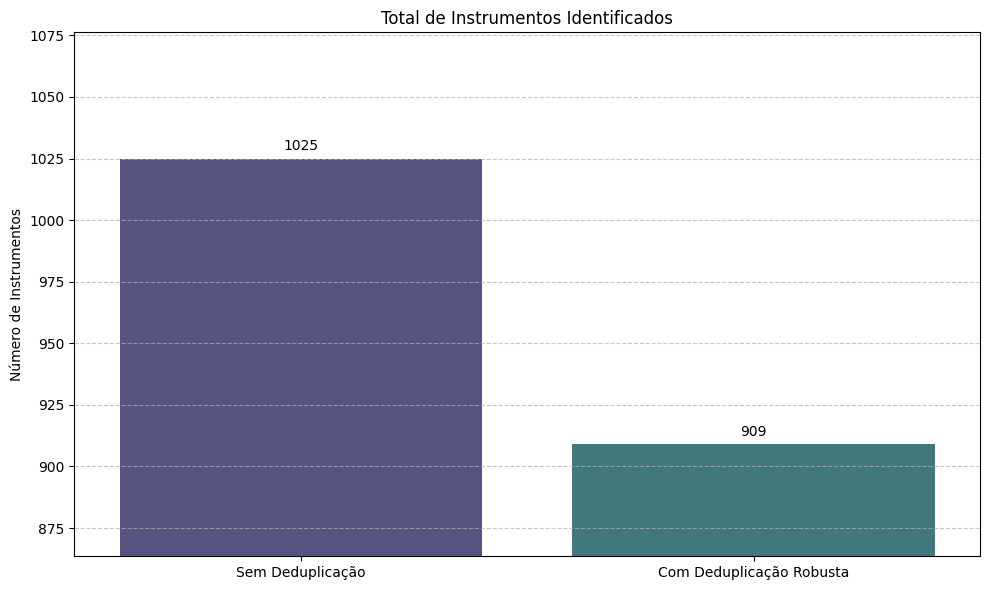

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total instruments without deduplication (non-null 'nm_ins')
total_no_deduplication = df_consolidated['nm_ins'].count()

# Calculate total unique instruments with deduplication (unique cluster_id)
# Ensure cluster_id is not NaN if there were entries that couldn't be clustered
total_with_deduplication = df_consolidated['cluster_id'].dropna().nunique()

# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Tipo de Contagem': ['Sem Deduplicação', 'Com Deduplicação Robusta'],
    'Número de Instrumentos': [total_no_deduplication, total_with_deduplication]
})

print("Comparativo de Instrumentos:")
display(comparison_df)

plt.figure(figsize=(10, 6))

# Define custom colors: 'Sem Deduplicação' (blue), 'Com Deduplicação Robusta' (green)
#custom_palette = {'Sem Deduplicação': 'blue', 'Com Deduplicação Robusta': 'green'}
custom_palette = {'Sem Deduplicação': '#504C88', 'Com Deduplicação Robusta': '#368087'}

ax = sns.barplot(x='Tipo de Contagem', y='Número de Instrumentos', data=comparison_df,
                 palette=custom_palette, hue='Tipo de Contagem', legend=False)

plt.title('Total de Instrumentos Identificados')
plt.xlabel('')
plt.ylabel('Número de Instrumentos')

# Set y-axis limits to effectively 'remove' numbers from 0 to 800 (start from a higher value)
min_count = min(total_no_deduplication, total_with_deduplication)
start_ylim = max(800, min_count * 0.95)

plt.ylim(start_ylim, max(total_no_deduplication, total_with_deduplication) * 1.05)

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Comparativo de Instrumentos:


,Tipo de Contagem,Número de Instrumentos
0,Sem Deduplicação,1025
1,Com Deduplicação Robusta,909


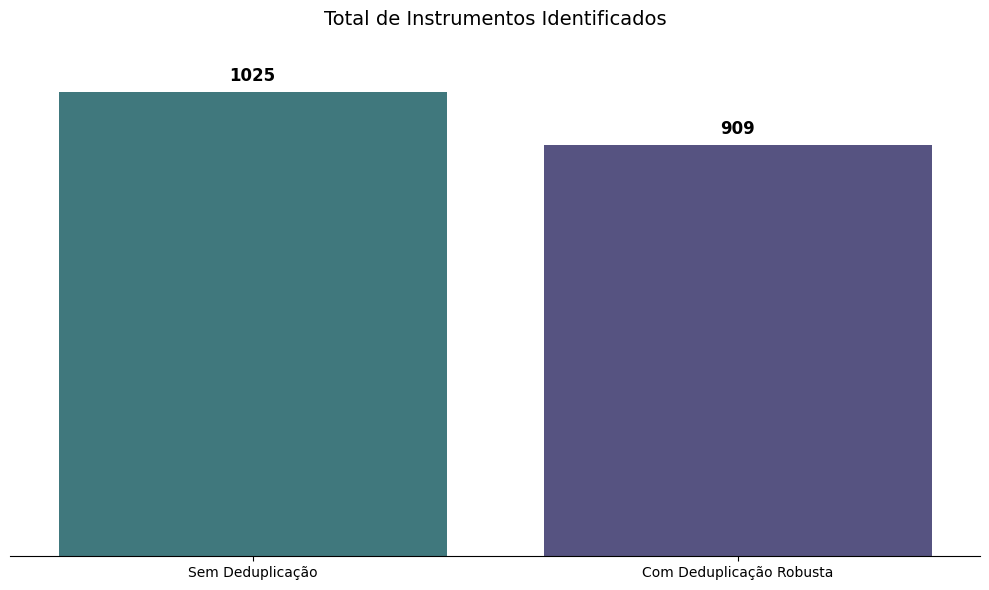

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# (Seus cálculos de total_no_deduplication e total_with_deduplication continuam aqui...)

# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Tipo de Contagem': ['Sem Deduplicação', 'Com Deduplicação Robusta'],
    'Número de Instrumentos': [total_no_deduplication, total_with_deduplication]
})

print("Comparativo de Instrumentos:")
display(comparison_df)

plt.figure(figsize=(10, 6))

# Paleta com as cores da imagem anterior (inverti a ordem para bater certinho com as chaves)
custom_palette = {'Sem Deduplicação': '#368087', 'Com Deduplicação Robusta': '#504C88'}

ax = sns.barplot(x='Tipo de Contagem', y='Número de Instrumentos', data=comparison_df,
                 palette=custom_palette, hue='Tipo de Contagem', legend=False)

plt.title('Total de Instrumentos Identificados', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('') # Remove o título do eixo Y já que não há números

# --- O QUE MUDOU DAQUI PARA BAIXO ---

# 1. Esconde completamente a escala de números e os risquinhos do eixo Y
ax.get_yaxis().set_visible(False)

# 2. Remove as bordas do gráfico (Y esquerdo e topo) para um visual mais limpo
sns.despine(left=True, top=True, right=True)

# 3. Ajusta o limite do eixo Y para dar um respiro para o texto no topo
max_value = max(total_no_deduplication, total_with_deduplication)
plt.ylim(0, max_value * 1.1) # Começa do 0 para a barra fazer sentido visualmente

# 4. Adiciona os números no topo de cada barra de forma nativa e robusta
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=5, fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

### Contagem de Instrumentos por Categoria (Multi-Label, Ordenado)

Calculando a contagem de instrumentos por categoria (multi-label) e ordenando...
Top 10 Categorias por número de Instrumentos (nm_ins):


,categ,count
15,Governança Digital,481
8,Coprodução de Valor Público,354
0,Automatização e IA,266
4,Cidadania Digital,209
21,Insights e Dados para Participação Cidadã,152
2,Canal inteligente de serviços,135
19,Governo Digital Proativo,102
10,Evolução de leis e normas,85
18,Governo Digital,18
5,Comunicação/Whatsapp,17


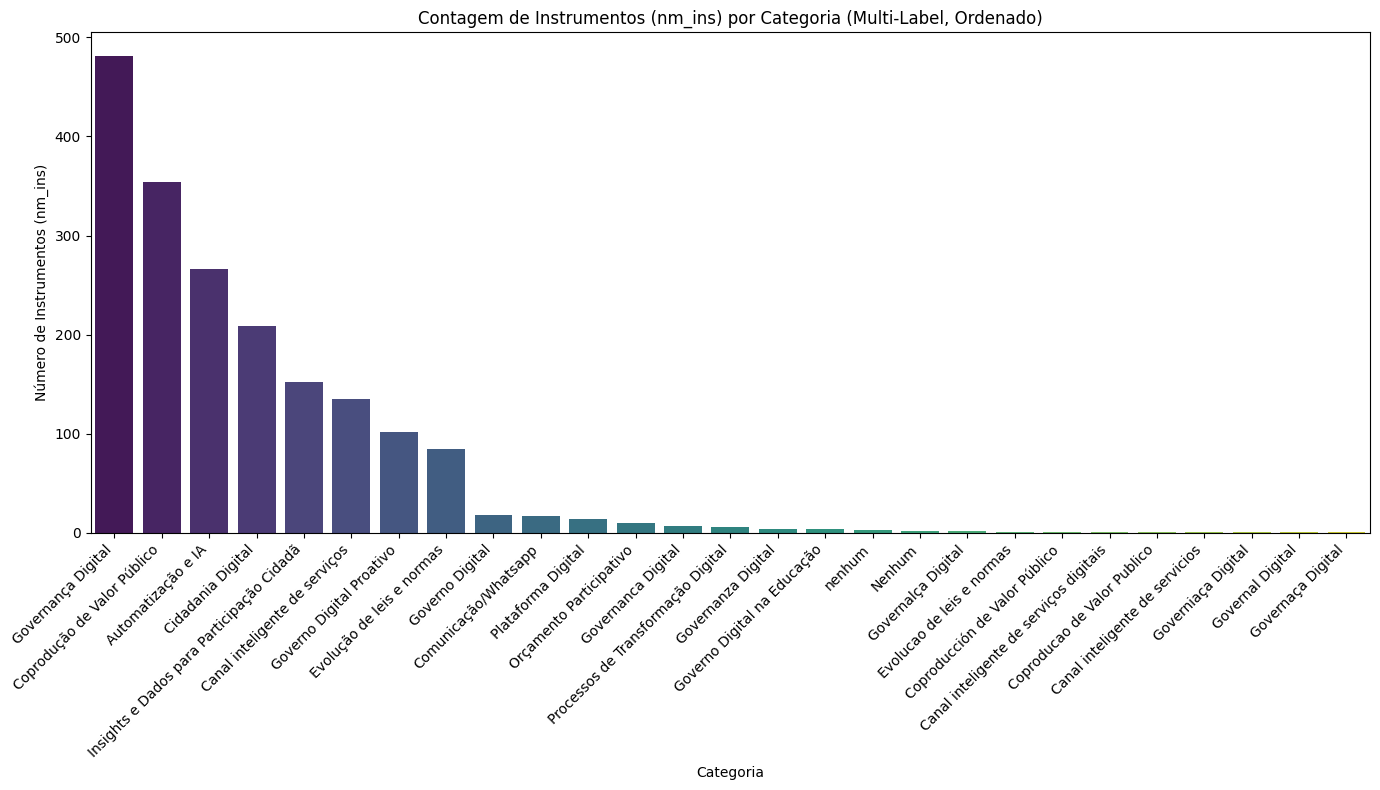

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando a contagem de instrumentos por categoria (multi-label) e ordenando...")

# Recalculate category counts from df_expanded to ensure it's up-to-date
# This counts each (instrument_name, category) pair, effectively 'nm_ins' occurrences per individual category
category_counts_nm_ins = df_expanded.groupby('categ')['nm_ins'].count().reset_index()
category_counts_nm_ins.rename(columns={'nm_ins': 'count'}, inplace=True)

# Sort by count in descending order
category_counts_nm_ins = category_counts_nm_ins.sort_values(by='count', ascending=False)

print("Top 10 Categorias por número de Instrumentos (nm_ins):")
display(category_counts_nm_ins.head(10))

# Plotting the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='categ', y='count', data=category_counts_nm_ins, palette='viridis', hue='categ', legend=False)
plt.title('Contagem de Instrumentos (nm_ins) por Categoria (Multi-Label, Ordenado)')
plt.xlabel('Categoria')
plt.ylabel('Número de Instrumentos (nm_ins)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Contagem de Instrumentos Únicos por Categoria (Multi-Label, Com Deduplicação Robusta, Ordenado)

Calculando a contagem de instrumentos únicos por categoria (multi-label, com deduplicação) e ordenando...
Top 10 Categorias por Instrumentos Únicos (multi-label, com deduplicação):


,categ,count
15,Governança Digital,447
8,Coprodução de Valor Público,330
0,Automatização e IA,251
4,Cidadania Digital,178
21,Insights e Dados para Participação Cidadã,144
2,Canal inteligente de serviços,120
19,Governo Digital Proativo,101
10,Evolução de leis e normas,80
18,Governo Digital,18
5,Comunicação/Whatsapp,13


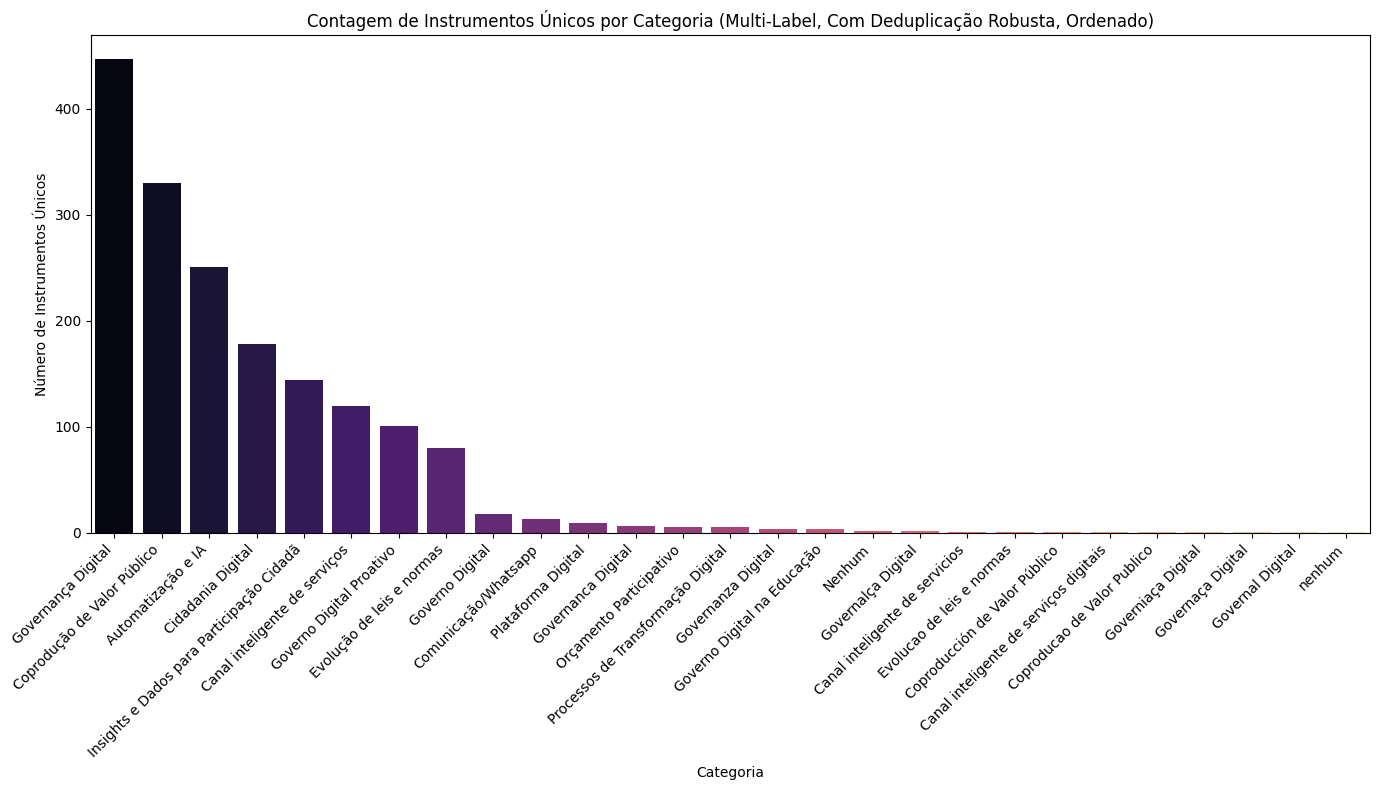

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando a contagem de instrumentos únicos por categoria (multi-label, com deduplicação) e ordenando...")

# Para contar instrumentos únicos por categoria, consideramos cada par (cluster_id, categ) único no DataFrame expandido.
# Isso garante que se um instrumento deduplicado (cluster_id) aparece em várias categorias,
# ele será contado para cada categoria individual em que aparece.
unique_instrument_category_pairs_multi = df_expanded[['cluster_id', 'categ']].drop_duplicates()

# Contar esses pares únicos por categoria
category_counts_multi_deduplicated = unique_instrument_category_pairs_multi.groupby('categ')['cluster_id'].count().reset_index()
category_counts_multi_deduplicated.rename(columns={'cluster_id': 'count'}, inplace=True)

# Classificar por contagem em ordem decrescente
category_counts_multi_deduplicated = category_counts_multi_deduplicated.sort_values(by='count', ascending=False)

print("Top 10 Categorias por Instrumentos Únicos (multi-label, com deduplicação):")
display(category_counts_multi_deduplicated.head(10))

# Plotting the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='categ', y='count', data=category_counts_multi_deduplicated, palette='magma', hue='categ', legend=False)
plt.title('Contagem de Instrumentos Únicos por Categoria (Multi-Label, Com Deduplicação Robusta, Ordenado)')
plt.xlabel('Categoria')
plt.ylabel('Número de Instrumentos Únicos')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

---

### 🎯 Resultados Finais da Dissertação e exportação dos instrumentos únicos

O *dataframe* `df_consolidated` resultante do código acima já contém todos os dados estruturados e os identificadores `cluster_id` necessários para obter os resultados finais do PTT.

**1. Consolidação dos 909 Instrumentos Únicos**
A aplicação do agrupamento hierárquico reduz a matriz de 1.025 registros para **909 instrumentos únicos**.

**2. Exportação do Arquivo Final do PTT**
Para salvar a base final consolidada com os clusters atribuídos diretamente em arquivo Excel.

Para isso, utilize o comando:

In [34]:
# Comando para filtrar 909 instrumentos únicos
df_ins_unicos = df_consolidated.drop_duplicates(subset=['cluster_id'])
df_ins_unicos.groupby('categ')['nm_ins'].count().sort_values(ascending=False)

# Comando para salvar o novo dataset final
df_ins_unicos.to_excel('df_ins_unicos.xlsx', index=False)
print("Dataset 'df_ins_unicos.xlsx' salvo com sucesso.")

Dataset 'df_ins_unicos.xlsx' salvo com sucesso.


2. Isolamento do Paradigma do Governo Agêntico (176 Ocorrências)
A subamostra de 176 ocorrências vinculadas à orquestração multiagente e IA generativa (Analisadas na Seção 4.1.1 e Figura 6 da dissertação) é obtida filtrando o campo uso_evid_orq_mult_IA:

# Comando para isolar ocorrências de Governo Agêntico

**critério: coluna uso_evid_orq_mult_IA  contendo o texto What**

In [46]:
import re

# O filtro no Excel é CONTÉM "What" para obter 176 registros.
# Este filtro deve ser aplicado ao DataFrame completo (df_consolidated) para replicar o resultado do Excel,
# já que o df_ins_unicos é deduplicado e pode ter removido algumas ocorrências.
df_ins_uso_evid_orq_mult_IA = df_consolidated[
    df_consolidated['uso_evid_orq_mult_IA'].astype(str).str.contains('What', case=False, na=False)
].copy()

# Salvar o DataFrame filtrado em um arquivo Excel com o nome especificado pelo usuário
df_ins_uso_evid_orq_mult_IA.to_excel('df_ins_uso_evid_orq_mult_IA.xlsx', index=False)
print(f"Dataset 'df_ins_uso_evid_orq_mult_IA.xlsx' salvo com {len(df_ins_unicos_filtered)} registros.")

Dataset 'df_ins_uso_evid_orq_mult_IA.xlsx' salvo com 176 registros.


#Geração de gráfico de Instrumentos com evidência de Uso associável a Orquestração multiagente

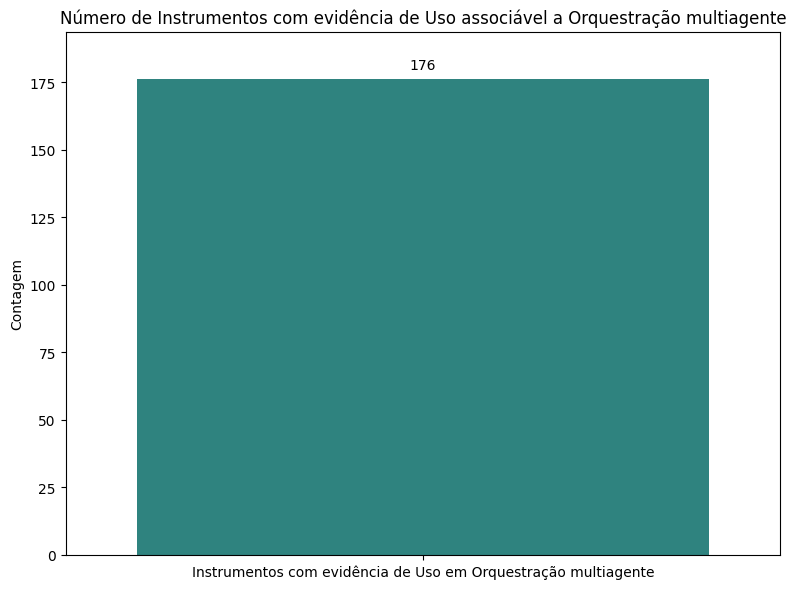

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Contar o número de registros no DataFrame filtrado
count_filtered = len(df_ins_uso_evid_orq_mult_IA)

# Criar um DataFrame para o gráfico
plot_data = pd.DataFrame({
    'Tipo': ['Instrumentos com evidência de Uso em Orquestração multiagente'],
    'Contagem': [count_filtered]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo', y='Contagem', data=plot_data, palette='viridis', hue='Tipo', legend=False)
plt.title('Número de Instrumentos com evidência de Uso associável a Orquestração multiagente')
plt.xlabel('')
plt.ylabel('Contagem')
plt.ylim(0, count_filtered * 1.1) # Ajusta o limite y para um bom espaçamento

# Adicionar o valor exato no topo da barra
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

Distribuição das 10 Macrocategorias de IA Mapeadas:

Sistemas de Decisão, Auditoria e Analítica Preditiva (58)

Sistemas de Automação, Interoperabilidade e APIs Públicas (30)

Ambientes Inteligentes de Aprendizagem Adaptativa (26)

Plataformas Inteligentes de Participação Cidadã e Cocriação (17)

Frameworks de Governança Ética, Transparência e Riscos de IA (14)

Plataformas Conversacionais e Chatbots de Linguagem Natural (10)

Arquiteturas de Orquestração Multiagente e Sistemas Autônomos (9)

Sistemas Gêmeos Digitais e Modelagem Ciber-Física (6)

Plataformas de Codificação Visual (Low-Code/No-Code) (3)

Tecnologias de Registros Distribuídos / Blockchain (3)